# Poster Picker

Search for a movie, fetch all variant posters from TMDB, and select a primary one.

In [16]:
MOVIE_NAME = "Inception"

In [17]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.fetch_posters import fetch_all_posters

await fetch_all_posters(MOVIE_NAME)

Cleared /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/
Found: Inception (id=27205)


Downloading: 100%|██████████| 62/62 [00:00<00:00, 103.17it/s]

Downloaded 62/62 posters to /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/Inception/


In [18]:
import os
import shutil
from IPython.display import display, HTML
import ipywidgets as widgets
from src.fetch_posters import OUTPUT_DIR

# Find the movie folder (sanitized name)
safe_title = "".join(c if c.isalnum() or c in " -_" else "_" for c in MOVIE_NAME).strip()
movie_dir = OUTPUT_DIR / safe_title

# Fall back to first matching folder if exact match not found
if not movie_dir.exists():
    candidates = list(OUTPUT_DIR.iterdir())
    movie_dir = candidates[0] if candidates else None

assert movie_dir and movie_dir.exists(), f"No poster folder found in {OUTPUT_DIR}"

poster_files = sorted(movie_dir.glob("*.*"))
print(f"Found {len(poster_files)} posters in {movie_dir}/")

# Convert to paths relative to the notebook for HTML rendering
notebook_dir = Path.cwd()

# Display all posters in a grid
html_parts = [
    "<style>",
    ".poster-grid { display: flex; flex-wrap: wrap; gap: 16px; }",
    ".poster-card { text-align: center; cursor: pointer; border: 3px solid transparent; padding: 4px; border-radius: 8px; transition: border-color 0.15s; }",
    ".poster-card:hover { border-color: #aaa; }",
    ".poster-card.selected { border-color: #4CAF50; }",
    ".poster-card img { max-height: 300px; border-radius: 4px; }",
    ".poster-card .label { margin-top: 4px; font-size: 12px; color: #666; }",
    "</style>",
    '<div class="poster-grid">',
]

for i, p in enumerate(poster_files):
    try:
        rel_path = p.resolve().relative_to(notebook_dir)
    except ValueError:
        rel_path = os.path.relpath(p.resolve(), notebook_dir)
    html_parts.append(
        f'<div class="poster-card" data-pick="{i+1}">'
        f'<img src="{rel_path}" />'
        f'<div class="label">#{i+1} — {p.name}</div>'
        f"</div>"
    )

html_parts.append("</div>")
html_parts.append("""
<script>
(function() {
    var cards = document.querySelectorAll('.poster-card');
    cards.forEach(function(card) {
        card.addEventListener('click', function() {
            cards.forEach(function(c) { c.classList.remove('selected'); });
            card.classList.add('selected');
            var pick = card.getAttribute('data-pick');
            // Update the ipywidgets text field if it exists
            var el = document.querySelector('.pick-input input');
            if (el) {
                var nativeInputValueSetter = Object.getOwnPropertyDescriptor(window.HTMLInputElement.prototype, 'value').set;
                nativeInputValueSetter.call(el, pick);
                el.dispatchEvent(new Event('input', { bubbles: true }));
                el.dispatchEvent(new Event('change', { bubbles: true }));
            }
        });
    });
})();
</script>
""")

display(HTML("\n".join(html_parts)))

# Small input widget that JS updates when a poster is clicked
pick_input = widgets.IntText(value=1, description="Pick #:", layout=widgets.Layout(width="150px"))
pick_input.add_class("pick-input")
display(pick_input)

Found 63 posters in /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/Inception/


IntText(value=1, description='Pick #:', layout=Layout(width='150px'), _dom_classes=('pick-input',))

In [ ]:
import asyncio

print("Select a poster above within 5 seconds...")
await asyncio.sleep(5)

Select a poster above within 5 seconds...
Using poster #1


Selected poster #57: 057_en.jpg
Primary poster saved to: /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/primary/Inception.jpg


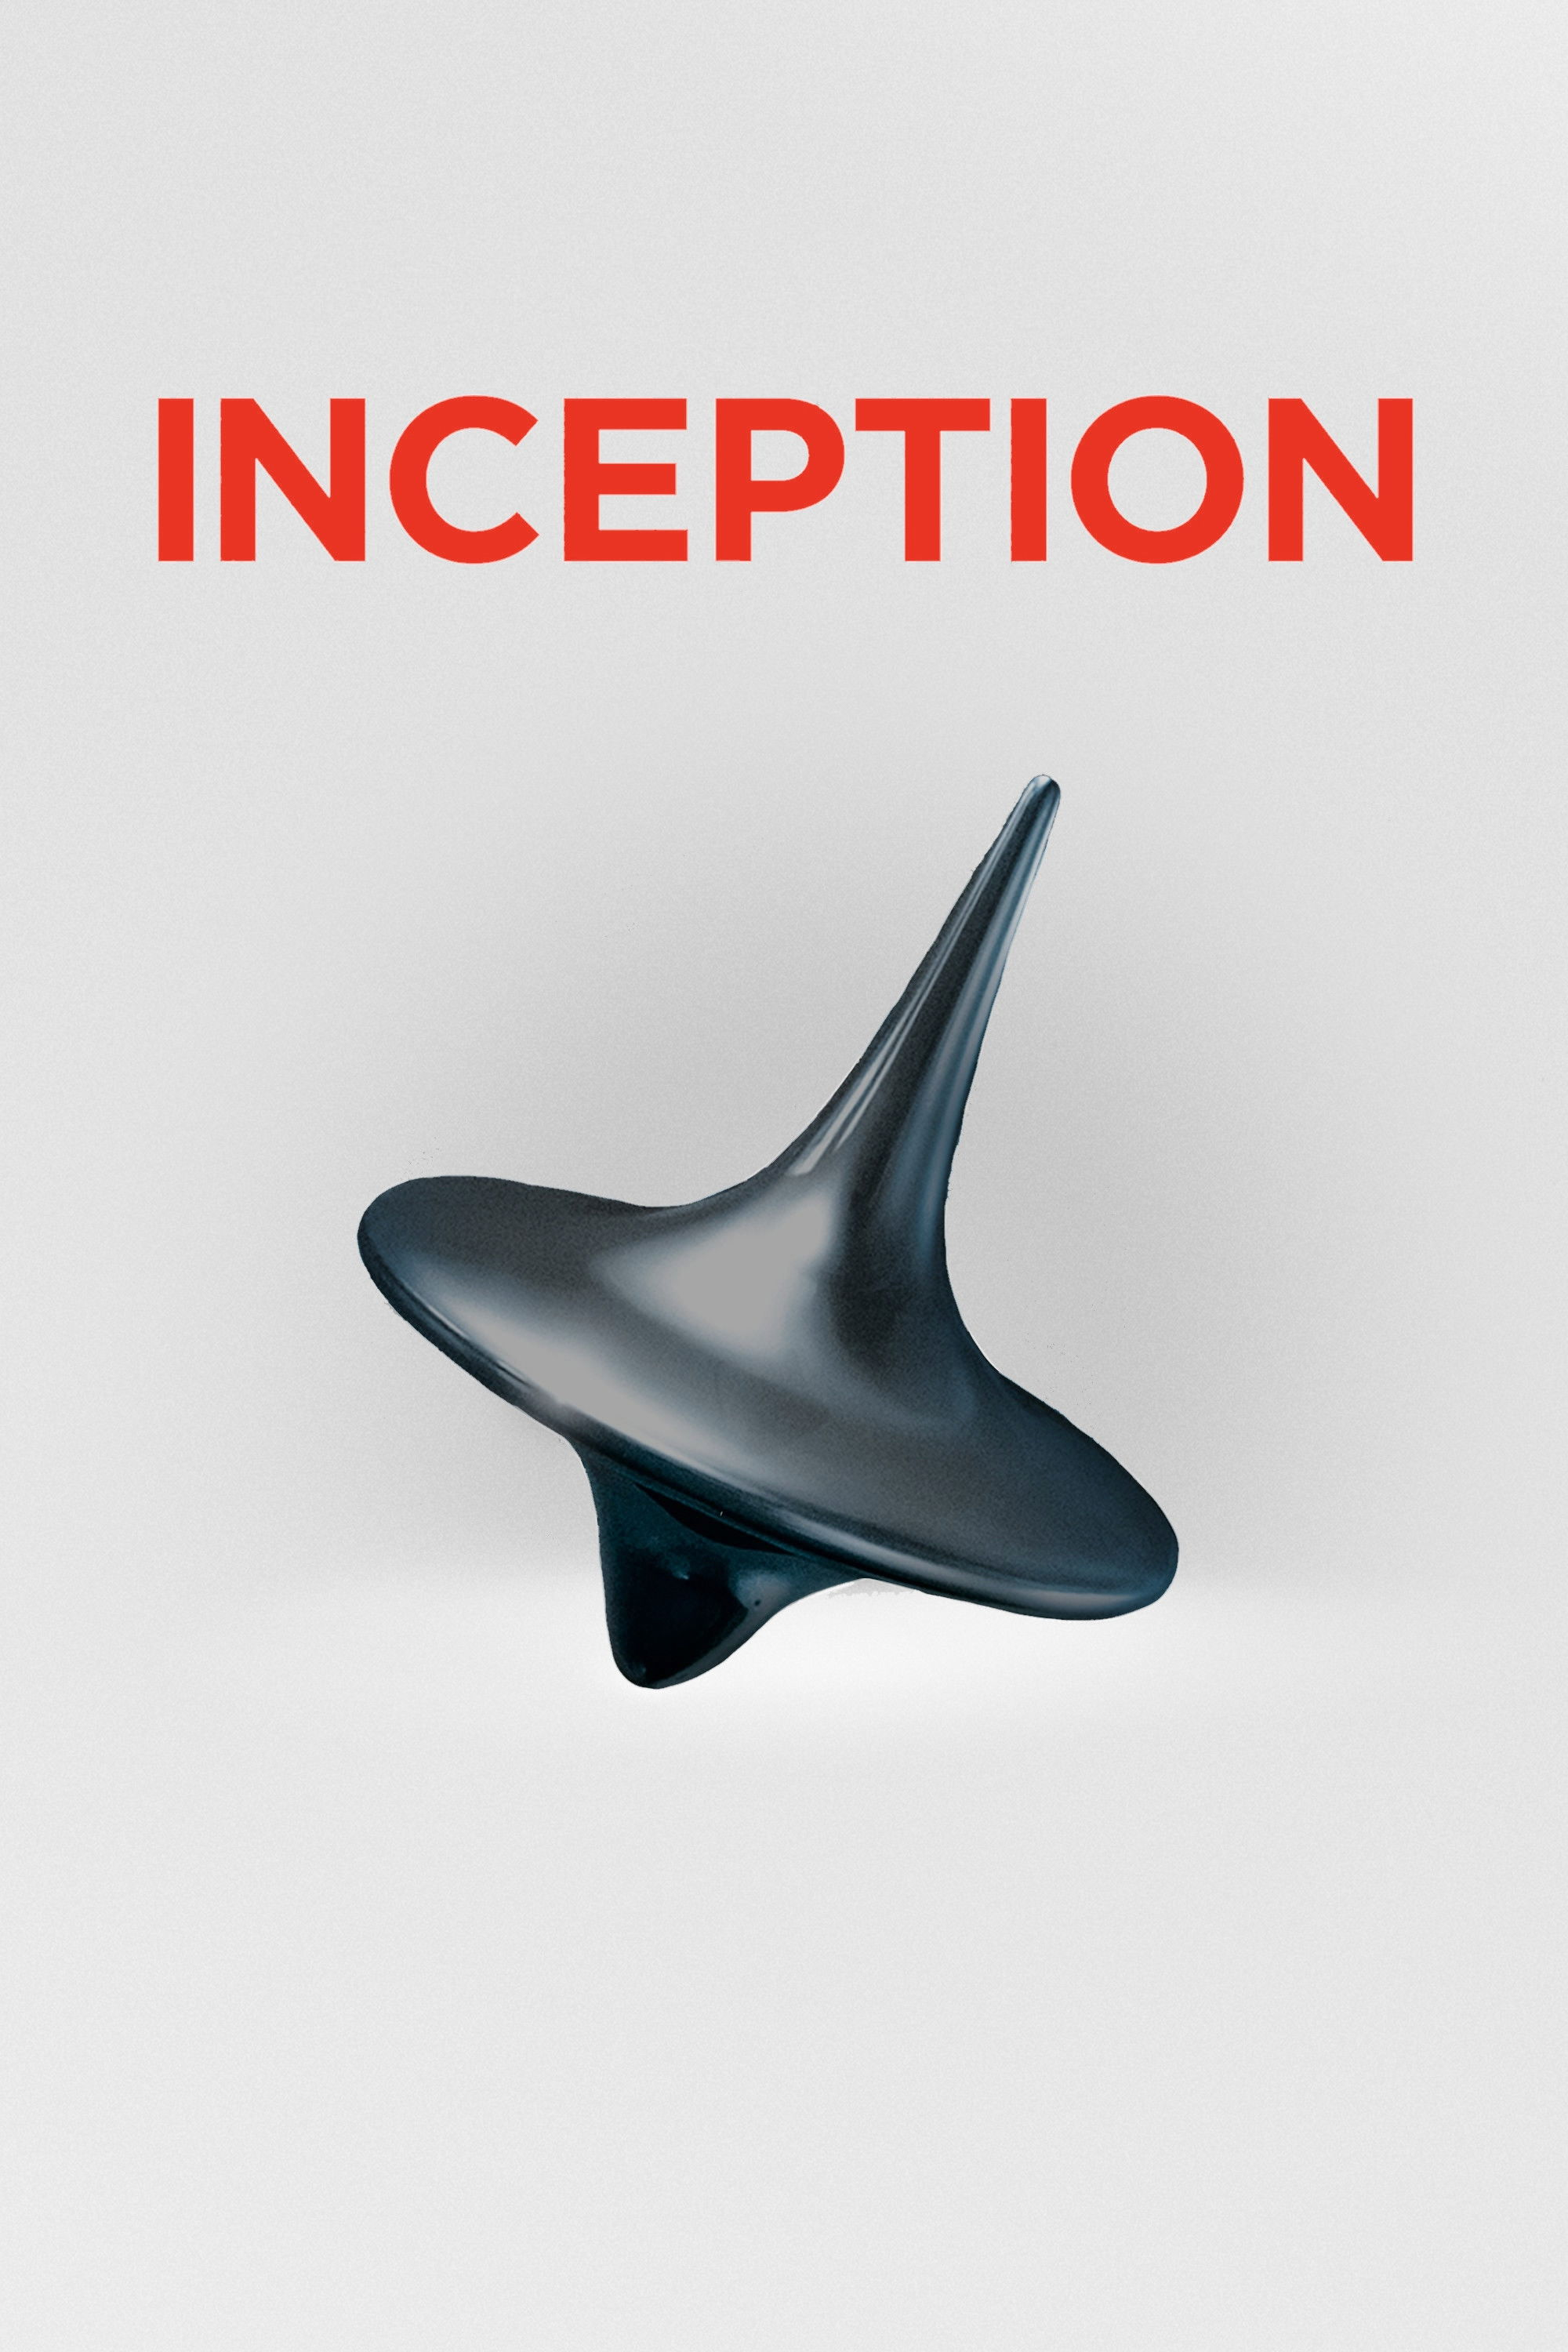

In [ ]:
# Finalize the selection and copy to primary poster
print(f"Using poster #{pick_input.value}")
PICK = pick_input.value

PRIMARY_DIR = OUTPUT_DIR / "primary"
PRIMARY_DIR.mkdir(parents=True, exist_ok=True)

chosen_file = poster_files[PICK - 1]
assert chosen_file.exists(), f"Poster file not found: {chosen_file}"

dest = PRIMARY_DIR / f"{safe_title}{chosen_file.suffix}"
shutil.copy2(chosen_file, dest)

print(f"Selected poster #{PICK}: {chosen_file.name}")
print(f"Primary poster saved to: {dest}")

from IPython.display import Image
Image(filename=str(dest), width=300)

## Feature Extraction

Run the feature extraction pipeline on all fetched posters for this movie.

In [21]:
from src.ImageToGenre_ClearnInterface import initialize_feature_models, acquire_poster_data
import json
import numpy as np
import pandas as pd

initialize_feature_models(verbose=True)

device: cuda
yolo: ok
easyocr: ok
mediapipe_face: error: face detector model not found at /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/data/face_detector.tflite
clip: ok
opennsfw2: ok


{'device': 'cuda',
 'yolo': 'ok',
 'easyocr': 'ok',
 'mediapipe_face': 'error: face detector model not found at /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/data/face_detector.tflite',
 'clip': 'ok',
 'opennsfw2': 'ok'}

In [22]:
OVERWRITE_FEATURES = False

features_path = movie_dir / "features.parquet"

if OVERWRITE_FEATURES and features_path.exists():
    features_path.unlink()
    print(f"Cleared {features_path}")

if features_path.exists():
    df_features = pd.read_parquet(features_path)
    df_features = df_features.set_index("poster") if "poster" in df_features.columns else df_features
    # Rebuild results dict from the cached df
    results = {name: row.to_dict() for name, row in df_features.iterrows()}
    print(f"Loaded cached features from {features_path} ({len(results)} posters)")
else:
    results = {}
    for i, poster_path in enumerate(poster_files, 1):
        print(f"[{i}/{len(poster_files)}] {poster_path.name}")
        try:
            results[poster_path.name] = acquire_poster_data(str(poster_path))
        except Exception as e:
            print(f"  FAILED: {e}")
    print(f"\nExtracted features for {len(results)}/{len(poster_files)} posters")

Loaded cached features from /mnt/c/Users/eicch/Documents/Documents/UChicago/Winter 2026/ADSP 32014 - Bayesian/FinalProject/requested_posters/Inception/features.parquet (62 posters)


In [23]:
if not features_path.exists():
    # Build summary table (drop large array columns like clip_embedding)
    rows = []
    for name, feats in results.items():
        row = {"poster": name}
        for k, v in feats.items():
            if not isinstance(v, (np.ndarray, dict, list)):
                row[k] = v
        rows.append(row)

    df_features = pd.DataFrame(rows).set_index("poster")
    df_features.to_parquet(features_path)
    print(f"Saved features to {features_path}")

print(f"{df_features.shape[0]} posters × {df_features.shape[1]} features")
df_features.head()

62 posters × 52 features


,path,width,height,brightness,contrast,saturation,warm_ratio,cool_ratio,warmth_score,color_entropy,...,title_position_y,stroke_width_mean,stroke_width_std,serifness_proxy,nsfw_score,center_distance,darkness,color_contrast_combo,warm_bright_combo,symmetry_edge_combo
poster,,,,,,,,,,,,,,,,,,,,,
001_en.jpg,/mnt/c/Users/eicch/Documents/Documents/UChicag...,682,1024,0.297273,0.247156,0.673306,0.117875,0.844781,-0.726906,5.725749,...,0.125000,2.733412,1.120481,0.001778,0.001228,0.120605,0.702727,0.166411,-0.216089,0.133459
002_en.jpg,/mnt/c/Users/eicch/Documents/Documents/UChicag...,682,1024,0.209308,0.235804,0.584227,0.193220,0.772606,-0.579385,4.986408,...,0.885742,3.229349,1.492161,0.000163,0.000666,0.091547,0.790692,0.137763,-0.121270,0.087579
003_en.jpg,/mnt/c/Users/eicch/Documents/Documents/UChicag...,682,1024,0.256774,0.172787,0.556381,0.039960,0.939987,-0.900027,5.505941,...,0.880859,2.489364,0.974012,0.005784,0.000122,0.022782,0.743226,0.096135,-0.231104,0.108567
004_en.jpg,/mnt/c/Users/eicch/Documents/Documents/UChicag...,682,1024,0.308449,0.215927,0.615664,0.055627,0.931389,-0.875762,5.966543,...,0.111328,2.450103,1.004826,0.005111,0.000269,0.023813,0.691551,0.132938,-0.270127,0.082962
005_en.jpg,/mnt/c/Users/eicch/Documents/Documents/UChicag...,682,1024,0.229837,0.212851,0.674684,0.011787,0.980976,-0.969188,5.259574,...,0.416016,2.593907,1.196874,0.010011,0.000011,0.023245,0.770163,0.143607,-0.222755,0.185634


## Predicted Genre averaged across all variant posters

Average genre probabilities across 62 poster variants:
  Horror: 0.3257
  Action: 0.3007
  Drama: 0.2886
  Animation: 0.0445
  Comedy: 0.0405


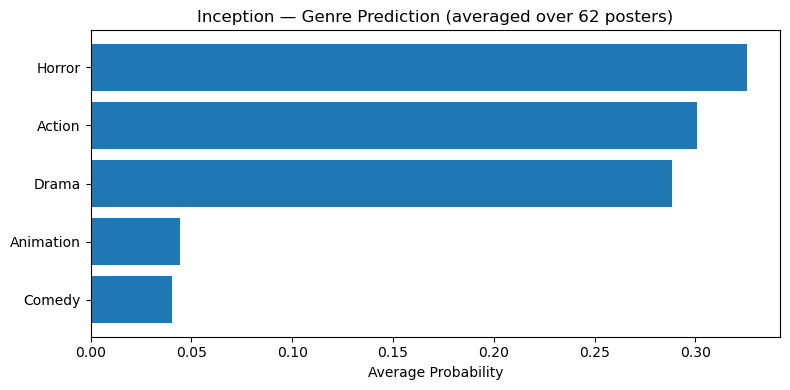

In [24]:
import matplotlib.pyplot as plt
from src.ImageToGenre_ClearnInterface import predict_genre_from_poster_dict

# Predict genre for every poster variant
all_probs = []
for name, poster_data in results.items():
    probs = predict_genre_from_poster_dict(poster_data)
    all_probs.append(probs)

# Average probabilities across all variants
genres = sorted(all_probs[0].keys())
avg_probs = {g: np.mean([p[g] for p in all_probs]) for g in genres}
avg_probs = dict(sorted(avg_probs.items(), key=lambda x: -x[1]))

print(f"Average genre probabilities across {len(all_probs)} poster variants:")
for g, p in avg_probs.items():
    print(f"  {g}: {p:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(list(reversed(avg_probs.keys())), list(reversed(avg_probs.values())))
ax.set_xlabel("Average Probability")
ax.set_title(f"{MOVIE_NAME} — Genre Prediction (averaged over {len(all_probs)} posters)")
plt.tight_layout()
plt.show()

## ChangeGenre - what to change to make chosen poster a different style

In [25]:
from src.ImageToGenre_ClearnInterface import predict_genre_from_poster_dict, ChangeGenre

chosen_name = chosen_file.name
poster_data = results[chosen_name]

probs = predict_genre_from_poster_dict(poster_data)
top_genre = max(probs, key=probs.get)
print(f"Predicted genre: {top_genre}")
for genre, prob in sorted(probs.items(), key=lambda x: -x[1]):
    print(f"  {genre}: {prob:.4f}")

print()
change = ChangeGenre(poster_data, "Comedy")
print(f"To shift to Comedy: {change['changed_nodes']}")
print(f"New distribution: {change['new_distribution']}")

Predicted genre: Drama
  Drama: 0.6580
  Comedy: 0.2584
  Horror: 0.0721
  Action: 0.0085
  Animation: 0.0031

To shift to Comedy: {'edge_density_bin': {'from': 'low', 'to': 'high'}}
New distribution: {'Action': np.float64(0.024101591188139534), 'Animation': np.float64(0.015133625374229638), 'Comedy': np.float64(0.5534447849408194), 'Drama': np.float64(0.3773265574615968), 'Horror': np.float64(0.02999344103521468)}
